In [12]:
import numpy as np
import matplotlib.pyplot as plt


# functions

In [13]:
def read_gro_file(gro_file:str,convert:float=10) -> dict:
 """ 
 read in a gromacs .gro file and 
 return a list with entires of a
 dictionary with atom names and 
 positions.

 this way i can select atoms
 by name. 
 and since it is a dictionary
 i (or you) can add any new per-atom
 or per-molecule fields :)  

 parameters
 ----------
 :param gro_file: gromacs .gro file
 :param convert: conversion factor for coord 
 returns
 -------
 dictionary with { resname-atomname : {resname,atom,distance} }
                    ^ since files may contain atoms with the same name 
 
 WARNING!!! FAILS FOR SINGLE ATOM
 TODO: make class(dict), so we can call to get certain params, and also add new ones
 gro_reader.coords = [x,y,z]
 gro_reader.sigmas = 1
 gro_reader.qs = [1,2,3]
 etc.
 """
 # dont make fun of me this is the fastest way to do this
 names = np.genfromtxt(gro_file,skip_header=2,skip_footer=1,usecols=(0,1,2),dtype='U16')
 dat = np.genfromtxt(gro_file,skip_header=2,skip_footer=1,usecols=(3,4,5),dtype='float')

 #atomarray = [{"res":ai[0],'atom':ai[1],"r": bi} for ai, bi in zip(names,dat)]
 return dict(zip(['-'.join(row) for row in names],[{"res":ai[0],'atom':ai[1],"r": convert*bi} for ai, bi in zip(names,dat)]))


In [5]:
dat2 = read_gro_file('methane.gro')
#dat2['1MOL-C1']['r'] += 20
dat2


{'1MOL-C1-1': {'res': np.str_('1MOL'),
  'atom': np.str_('C1'),
  'r': array([15., 15., 15.])},
 '1MOL-H1-2': {'res': np.str_('1MOL'),
  'atom': np.str_('H1'),
  'r': array([15.55, 15.8 , 15.5 ])},
 '1MOL-H2-3': {'res': np.str_('1MOL'),
  'atom': np.str_('H2'),
  'r': array([15.68, 14.19, 14.75])},
 '1MOL-H3-4': {'res': np.str_('1MOL'),
  'atom': np.str_('H3'),
  'r': array([14.22, 14.63, 15.67])},
 '1MOL-H4-5': {'res': np.str_('1MOL'),
  'atom': np.str_('H4'),
  'r': array([14.54, 15.39, 14.09])}}

In [6]:
for nam in dat2:
    print("-".join(nam.split("-")[:2]))

1MOL-C1
1MOL-H1
1MOL-H2
1MOL-H3
1MOL-H4


## Topology reader

In [7]:
def read_top_and_get_charge(top_file:str) -> dict:
    """
    read gromacs .top file and read the section
    [ atoms ] to get per-atom charge

    :warning: only works if you have the entire 
    [ atoms ] written to the .top file (i.e. i
    wont search for the #include libraries)
    you can make this by using
    ```
    x = Parmed.load_file(your.top)
    x.save(new.top)
    ```

    parameters
    ----------
    :param top_file: gromacs.top file (see warning)

    returns
    -------
    dictionary with entries identical to 
    read_gro_file
    { residresname-atomname : { charge } }
    """
    # TODO: make better
    to_go = {} # empty dict 
    # --------------------------------- START READ
    with open(top_file,'r') as topfile:
        flag = False
        for line in topfile:
            if line.strip() == '[ atoms ]':
                flag = True
                continue
            if line.strip() in ('[ bonds ]','[ angles ]','[ system ]','[ molecules ]'):
                flag = False
                break
            if flag:
                if line.startswith(";"):
                    continue
                else:
                    tmp = line.split()
                    #print(tmp)
                if not tmp:
                    # skip empty rows
                    continue
                else:
                    resid = tmp[2]
                    resname = tmp[3]
                    atomname = tmp[4]
                    charge = float(tmp[6])
                    # add to dict
                    to_go[resid+resname+'-'+atomname] = charge
    # --------------------------------- END READ
    return to_go

In [8]:
read_top_and_get_charge('methane.top')

{'1MOL-C1': -0.1087,
 '1MOL-H1': 0.0272,
 '1MOL-H2': 0.0272,
 '1MOL-H3': 0.0272,
 '1MOL-H4': 0.0272}

## get solvent potential

In [9]:
from episol.data import *# load_episol_ascii


In [10]:
dat = load_episol_ascii('guv_methane.txt')

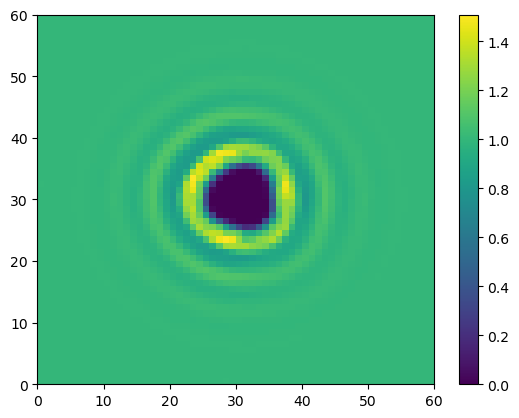

In [14]:
fig,axs = plt.subplots()

p = axs.pcolormesh(dat[30])
fig.colorbar(p,ax=axs)

In [15]:
from episol.selection_tools import wrap_sel
from episol.fileutils import debugger

def wrap_get_distance_single(cell_shape,in_coords:list,around:float=None,conversion:float=1,debug:bool=False):
    """
    Return an array of distances (in A) around a selection 

    USING MINIMUM IMAGE CONVENTION

    only works if box is centered at [0,0,0], and extends in the
    positive direction..
    there is no way to determine
    the coordinates/location of our 3D data box, just given 3d data
    so we assume it starts at the origin...
    
    ----------------------
    |                    |
    |        atom-1      |
    |                    |
    |       atom-2       |                     
    |                    |
    ----------------------
    ^
    start (0,0,0)

    Parameters
    ----------
    :param cell_shape: length of the cell ( IN ANGSTROM) that the calculation was performed in. we assume it is centered at 
    the origin and will be used to construct the distance array
    :param in_coords: center of radii to be selected around. ( Angstrom )
    :param around: Cutoff distance to use for selection ( IN ANGSTROM! )
    :param conversion: resolution of grid ( Angstrom )
    :param debug: print info

    returns
    -------
    rism_grid: numpy.ndarray values on gridpoints from 3drism calc
    d_grid: numpy.ndarray of square distances for all cells
    """
    from episol.fileutils import debugger

    debug_msg = "# [ WRAP DISTANCES ]:"
    debugger = debugger(debug_msg,debug)


    # ------------------------------------- convert A to grid
    cell_shape = [int(i/conversion) for i in cell_shape]
    min_dist = 0.5 * np.min(cell_shape) #/ conversion
    in_coords = [i/conversion for i in in_coords]
    # --------------------------------------
    if around:
        around = around/conversion # must convert A to grids
        if around > min_dist:
            print(debug_msg,"WARNING, you selected greater than 1/2 the min box length. this will overlap distances")
    else:
        around = min_dist
    #rism_grid = np.copy(rism_grid) # should auto convert to numpy
    # -------------------------------------------------------------------------------------
    # now, get max and min of our box..
    max_box_x = cell_shape[0] 
    max_box_y = cell_shape[1] 
    max_box_z = cell_shape[2] 
    min_box = 0.0 # always the same
    stage = debugger.db(f"USING CELL: {cell_shape}")
    stage = debugger.db(f"SELECTING AROUND: {cell_shape}")
    stage = debugger.db(f"USING COORDS: {in_coords}")
    # this is dumb
    wrap = lambda in_coord, box_L: in_coord - box_L if in_coord >= box_L else (in_coord + box_L if in_coord <= 0.0 else in_coord)
    ########## START ##########
    # TODO: this is wasteful
    x = np.arange(0,max_box_x)
    y = np.arange(0,max_box_y)
    z = np.arange(0,max_box_z)
    #TODO: oof, also wastefull
    # should be int as grids 
    d_grid = np.full((max_box_x,max_box_y,max_box_z),0.0,dtype='float')
    # TODO
    # need to speed this up..
    # now, wrap coords if need be
    x_r = wrap(in_coords[0],max_box_x)
    y_r = wrap(in_coords[1],max_box_y)
    z_r = wrap(in_coords[2],max_box_z)
    # TODO: this is bad

    x_dist = wrap_sel(one_d_array=x,starting_point=x_r,distance=around,array_max=max_box_x)
    y_dist = wrap_sel(one_d_array=y,starting_point=y_r,distance=around,array_max=max_box_y)
    z_dist = wrap_sel(one_d_array=z,starting_point=z_r,distance=around,array_max=max_box_z)
    # TODO: clean this
    #rism_grid[(x[:,np.newaxis,np.newaxis]-x_r)**2+(y[np.newaxis,:,np.newaxis]-y_r)**2+(z[np.newaxis,np.newaxis,:]-z_r)**2 > around**2] = np.nan
    #d_grid = x_dist[:,np.newaxis,np.newaxis] + y_dist[np.newaxis,:,np.newaxis] + z_dist[np.newaxis,np.newaxis,:] 
    #rism_grid[x_dist[:,np.newaxis,np.newaxis]-x_r + y_dist[np.newaxis,:,np.newaxis] + z_dist[np.newaxis,np.newaxis,:] > around**2] = np.nan
    #rism_grid[d_grid > around**2] = np.nan
    #return rism_grid

    return x_dist[:,np.newaxis,np.newaxis] + y_dist[np.newaxis,:,np.newaxis] + z_dist[np.newaxis,np.newaxis,:] 

In [16]:
def get_solvent_potential(density_array,gro_file:str,topology_file:str,solv_q:list=None,rho:float=0.0034,
                          resolution_of_rism_calc:float=1,output_grid:bool=True,cutoff:float=None,
                          eps:float=1e-03,debug:bool=False) -> dict:
    r"""
    an ad hoc solvent potential grabber

    Given:
    1) a solute
    2) solvent density values surrounding the solute 
    3) charges for all solute and solvent species
    we can recreate the potential felt by the solute atoms as a function 
    of the solvent.

    here, we read in all of these parameters and return a dictionary
    of the potential imposed on the solute atoms. Solving this:

    :math:`V_i = \Sigma_{\rm solvent sites}\frac{q_i\Sigma_k q_k \rho^{bulk} l^3}{|r_i - r_k|}` 
    

    where l = grid length (resoultion)
    parameters
    ----------
    :param density_array: numpy ndarray of size ([box_len x box_len xbox_len] x n_solvent sites) 
    containing g(r) for each solvent species. 
    :param gro_file: the gromacs .gro file for our solute that the density_array arises from
    :param topology_file: gromacs .top file we used for the 3drism calc on the .gro file solute that
    resulted in the density_array g(r) values
    :param resolution_of_rism_calc: the resolutions (in Angstrom) of the cell voxels from the 3drism calc
    we got density_array values from this.
    :param cutoff: cutoff distance (in Angstrom) to get potential
    :param rho: number density of bulk solvent in 1 / A^3
    :param solv_q: charge for solvent sites, must be in the same order as the column data in the 
    density file. see episol_load_ascii which will be reading the density file. default is water-oxygen q
    :param eps: when distance to silute is zero, we get inf. so i add eps to distance=0.0
    :param debug: run verbose

    returns
    -------

    dictionary of:
    {'atoname' : { 'res':residue-name, 'atom': atom-type (from .top)
    'r':[x-coords,y-coords,z-coords],
    'q':charge-e,
    'V' : total-potential_imposed_by_solvent}


    """
    from episol.fileutils import debugger
    COUL_FACTOR = 1389.354846 # from (e^2/A) charge^2 / distance to kj/mol
    debug_msg = "# [ GET SOLV V]: "
    debugger = debugger(debug_msg,debug)
    # ---------------------------
    input_dim = len(density_array.shape) 
    if input_dim > 3:
        cell_shape = [i * resolution_of_rism_calc for i in density_array.shape[1:]]
    else:
        cell_shape = [i * resolution_of_rism_calc for i in density_array.shape]
    if not cutoff:
        cutoff = 0.5 * np.min(cell_shape) * resolution_of_rism_calc 
    cutoffsq = cutoff ** 2
    n_solv_sites = input_dim - 2 # dat1, ..datN, x,y,z
    stage = debugger.db(f"USING {n_solv_sites -2} SOLVENT SITES")
    if not solv_q:
        # assume water, and water order in the density file
        # using amber14sb.ff: https://github.com/gromacs/gromacs/blob/main/share/top/amber14sb.ff/tip3p.itp
        # Hydrogen first, then oxygen solv_q = [-0.834,0.417]
        solv_q = [0.417,-0.834]
        if input_dim == 3:
            solv_q = solv_q[0]
    stage = debugger.db(f"USING {solv_q} SOLVENT POTENTIALS")
    # --------------------------- START
    stage = debugger.db(f"OPENING FILE {topology_file}")
    top = read_top_and_get_charge(topology_file)
    stage = debugger.db(f"OPENING FILE {gro_file}")
    atoms = read_gro_file(gro_file)
    stage = debugger.db(f"SOLUTE HAS {len(atoms)} ATOMS")
    #
    stage = debugger.db(f"ASSIGNING CHARGES")
    for mol in atoms.keys():
        #TODO: check this 
        # dictionary is good for top reader. but bad for atoms 
        # as they will have same names
        t_mol_name = "-".join(mol.split("-")[:2])
        atoms[mol]['q'] = top[t_mol_name]
    stage = debugger.db(f"ASSIGNING CHARGES DONE")
    # ==================================================================================== LOOP THROUGH ATOMS
    if output_grid:
        solv_V = np.zeros_like(density_array)#*solute_q*solv_q * resolution_of_rism_calc**3 / dist_i
    # for each atom
    for atom in atoms.keys():
        # get the coords and charge
        coords = atoms[atom]['r'] 
        solute_q = atoms[atom]['q']

        # TODO: select between cuttoff and very small value to avoid inf?
        # for now i will just make dist=0 a very small number 1e-06  
        # -------------------------------------------------------------------------------- GET DISTANCE
        stage = debugger.db(f"STARTING ATOM {atom}")
        stage = debugger.db(f"USING COORDS {coords}")

        # get distance^2 and used for all solvent sites
        dist_i = wrap_get_distance_single(cell_shape=cell_shape,in_coords=coords,
                                          around=cutoff,conversion=resolution_of_rism_calc,
                                          debug=debug)
        # -------------------------------------------------------------------------------- END DISTANCE
        dist_i = np.where(dist_i==0.0,eps,dist_i) # add eps where our distance is zero
        # if we have a single solvent site
        if input_dim == 3:
            # we have a single solvent site
            # output solv pot at each grid for testing
            #solv_V = density_array,resolution_of_rism_calc**3 * g_r_i / dist_i
            #solv_V = np.ma.array(solv_V,mask=np.isnan(solv_V)) # TODO make ma-array to begin
            # selection is flattened but still retains ordering
            #dist_i = dist_i[~np.isnan(g_r_i)]
            #dist_i.shape
            #g_r_i = g_r_i[~np.isnan(g_r_i)] / dist_i 
            # for total-V : 
            atoms[atom]['V'] = np.sum(density_array[:,0]*solute_q*solv_q / dist_i) * resolution_of_rism_calc**3
            #atoms[atom]['V']['y'] = np.sum(density_array[:,1]*solute_q*solv_q / dist_i) * resolution_of_rism_calc**3
            #atoms[atom]['V']['z'] = np.sum(density_array[:,2]*solute_q*solv_q / dist_i) * resolution_of_rism_calc**3
            #atoms[atom]['V'] = np.sum(solv_V,axis=0).data
            if output_grid:
                solv_V += density_array*solute_q*solv_q * resolution_of_rism_calc**3 / dist_i
        # otherwise, each atom recives multiple input from solvent i.e. H and O for H2O
        # but our distance around each atom will be the same
        else:
            atoms[atom]['V'] = float()
            #atoms[atom]['V'] = {'x': float(),'y': float(),'z': float()}
  
            #print('ATOMS',atoms[atom]['V'])
            # for all solvent sites
            for ind,solv_q_i in enumerate(solv_q):
                # we have a single solvent site
                # output solv pot at each grid for testing
                atoms[atom]['V'] +=  resolution_of_rism_calc**3 * np.sum(density_array[ind]*solute_q*solv_q_i / dist_i)

            if output_grid:
                solv_V += density_array*solute_q*solv_q_i * resolution_of_rism_calc**3 / dist_i
            # ( v_1 + v_2 ) / 2
            atoms[atom]['V'] *= (rho* COUL_FACTOR) / n_solv_sites # convert to kj/mol

        # ------------------------------------------------------------------------------------------ DONE WITH GET GRID

    if output_grid:
        return rho*COUL_FACTOR*solv_V /n_solv_sites/len(atoms) , atoms
    else:
        return atoms

In [17]:
guv = load_episol_ascii('guv_methane.txt',col_to_select=[-1,-2])#.reshape(2,60,60,60)
guv.shape

(2, 60, 60, 60)

In [18]:
help(get_solvent_potential)

Help on function get_solvent_potential in module __main__:

get_solvent_potential(
    density_array,
    gro_file: str,
    topology_file: str,
    solv_q: list = None,
    rho: float = 0.0034,
    resolution_of_rism_calc: float = 1,
    output_grid: bool = True,
    cutoff: float = None,
    eps: float = 0.001,
    debug: bool = False
) -> dict
    an ad hoc solvent potential grabber

    Given:
    1) a solute
    2) solvent density values surrounding the solute
    3) charges for all solute and solvent species
    we can recreate the potential felt by the solute atoms as a function
    of the solvent.

    here, we read in all of these parameters and return a dictionary
    of the potential imposed on the solute atoms. Solving this:

    :math:`V_i = \Sigma_{\rm solvent sites}\frac{q_i\Sigma_k q_k \rho^{bulk} l^3}{|r_i - r_k|}`


    where l = grid length (resoultion)
    parameters
    ----------
    :param density_array: numpy ndarray of size ([box_len x box_len xbox_len] x n_sol

In [19]:
%%time

guv = load_episol_ascii('guv_methane.txt',col_to_select=[-1,-2])
dat = get_solvent_potential(guv,'methane.gro','methane.top',resolution_of_rism_calc=0.5,debug=True)


# [ GET SOLV V]:  USING 0 SOLVENT SITES
# [ GET SOLV V]:  USING [0.417, -0.834] SOLVENT POTENTIALS
# [ GET SOLV V]:  OPENING FILE methane.top
# [ GET SOLV V]:  OPENING FILE methane.gro
# [ GET SOLV V]:  SOLUTE HAS 5 ATOMS
# [ GET SOLV V]:  ASSIGNING CHARGES
# [ GET SOLV V]:  ASSIGNING CHARGES DONE
# [ GET SOLV V]:  STARTING ATOM 1MOL-C1-1
# [ GET SOLV V]:  USING COORDS [15. 15. 15.]
# [ WRAP DISTANCES ]: USING CELL: [60, 60, 60]
# [ WRAP DISTANCES ]: SELECTING AROUND: [60, 60, 60]
# [ WRAP DISTANCES ]: USING COORDS: [np.float64(30.0), np.float64(30.0), np.float64(30.0)]
# [ GET SOLV V]:  STARTING ATOM 1MOL-H1-2
# [ GET SOLV V]:  USING COORDS [15.55 15.8  15.5 ]
# [ WRAP DISTANCES ]: USING CELL: [60, 60, 60]
# [ WRAP DISTANCES ]: SELECTING AROUND: [60, 60, 60]
# [ WRAP DISTANCES ]: USING COORDS: [np.float64(31.099999999999998), np.float64(31.6), np.float64(31.0)]
# [ GET SOLV V]:  STARTING ATOM 1MOL-H2-3
# [ GET SOLV V]:  USING COORDS [15.68 14.19 14.75]
# [ WRAP DISTANCES ]: USING CELL

In [20]:
dat[1]

{'1MOL-C1-1': {'res': np.str_('1MOL'),
  'atom': np.str_('C1'),
  'r': array([15., 15., 15.]),
  'q': -0.1087,
  'V': np.float64(5.304137698042516)},
 '1MOL-H1-2': {'res': np.str_('1MOL'),
  'atom': np.str_('H1'),
  'r': array([15.55, 15.8 , 15.5 ]),
  'q': 0.0272,
  'V': np.float64(-1.3354106377563923)},
 '1MOL-H2-3': {'res': np.str_('1MOL'),
  'atom': np.str_('H2'),
  'r': array([15.68, 14.19, 14.75]),
  'q': 0.0272,
  'V': np.float64(-1.3370365386414946)},
 '1MOL-H3-4': {'res': np.str_('1MOL'),
  'atom': np.str_('H3'),
  'r': array([14.22, 14.63, 15.67]),
  'q': 0.0272,
  'V': np.float64(-1.3371771118689793)},
 '1MOL-H4-5': {'res': np.str_('1MOL'),
  'atom': np.str_('H4'),
  'r': array([14.54, 15.39, 14.09]),
  'q': 0.0272,
  'V': np.float64(-1.3374709877258004)}}

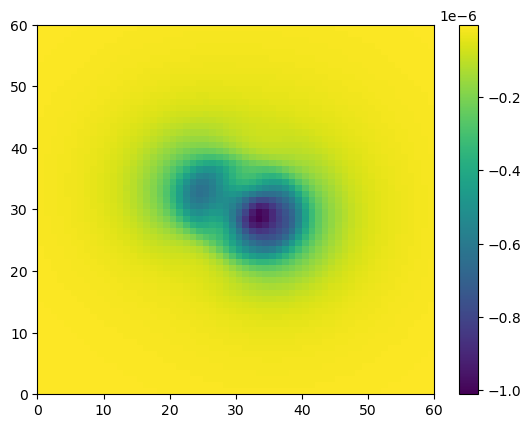

In [21]:
fig,axs = plt.subplots()
p = axs.pcolormesh(dat[0][1][20])
fig.colorbar(p,ax=axs)

# Uranium ion and Silver

In [22]:
guv = load_episol_ascii('guv_Ag+.txt',col_to_select=[-1,-2])
dat = get_solvent_potential(guv,'Ag+.gro','Ag+.top',resolution_of_rism_calc=0.5,debug=True)
dat[1]

# [ GET SOLV V]:  USING 0 SOLVENT SITES
# [ GET SOLV V]:  USING [0.417, -0.834] SOLVENT POTENTIALS
# [ GET SOLV V]:  OPENING FILE Ag+.top
# [ GET SOLV V]:  OPENING FILE Ag+.gro
# [ GET SOLV V]:  SOLUTE HAS 2 ATOMS
# [ GET SOLV V]:  ASSIGNING CHARGES
# [ GET SOLV V]:  ASSIGNING CHARGES DONE
# [ GET SOLV V]:  STARTING ATOM 1MOL-AG-1
# [ GET SOLV V]:  USING COORDS [10. 10. 10.]
# [ WRAP DISTANCES ]: USING CELL: [60, 60, 60]
# [ WRAP DISTANCES ]: SELECTING AROUND: [60, 60, 60]
# [ WRAP DISTANCES ]: USING COORDS: [np.float64(20.0), np.float64(20.0), np.float64(20.0)]
# [ GET SOLV V]:  STARTING ATOM 1MOL-AG-2
# [ GET SOLV V]:  USING COORDS [20. 20. 20.]
# [ WRAP DISTANCES ]: USING CELL: [60, 60, 60]
# [ WRAP DISTANCES ]: SELECTING AROUND: [60, 60, 60]
# [ WRAP DISTANCES ]: USING COORDS: [np.float64(40.0), np.float64(40.0), np.float64(40.0)]


{'1MOL-AG-1': {'res': np.str_('1MOL'),
  'atom': np.str_('AG'),
  'r': array([10., 10., 10.]),
  'q': 1.0,
  'V': np.float64(-53.7316560298266)},
 '1MOL-AG-2': {'res': np.str_('1MOL'),
  'atom': np.str_('AG'),
  'r': array([20., 20., 20.]),
  'q': 1.0,
  'V': np.float64(-52.88079232393287)}}

<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1474255/3661505255.py:9: SyntaxWarning: invalid escape sequence '\P'
  fig.colorbar(p,ax=ax,label="$\Phi$")


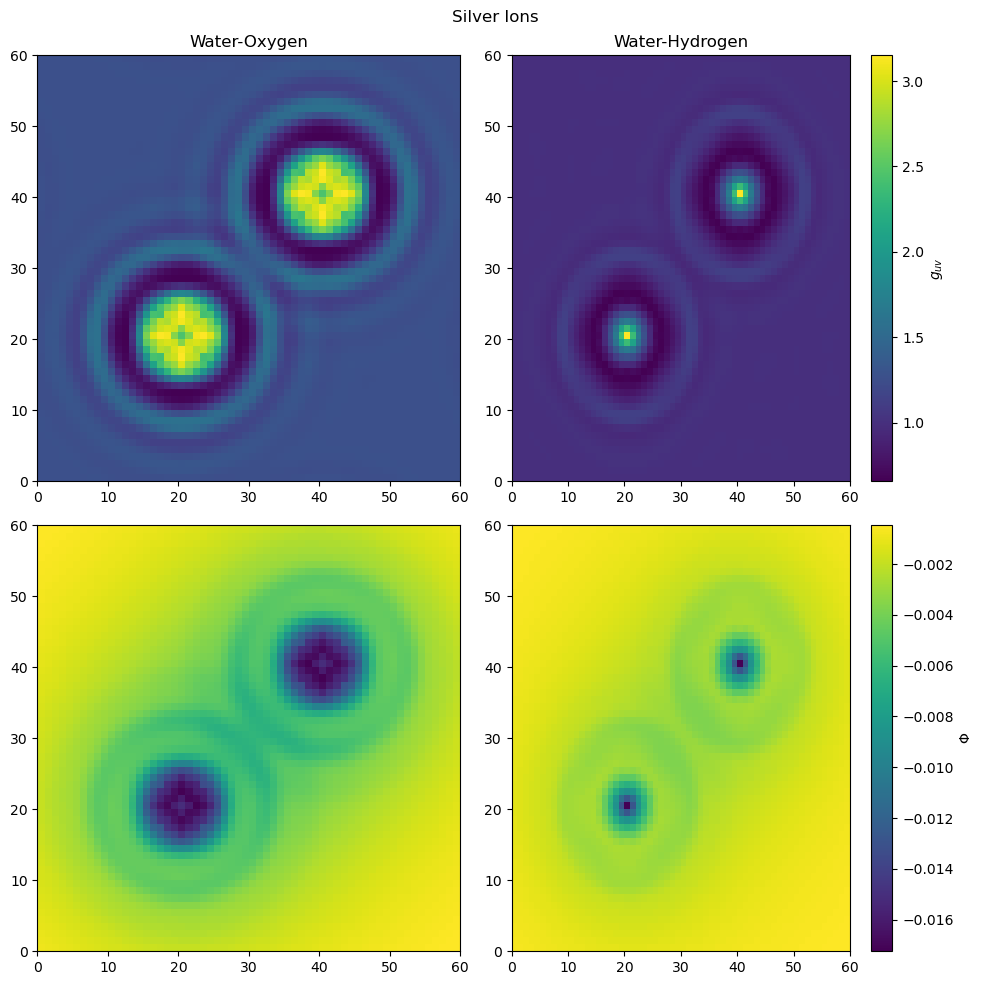

In [29]:
fig,axs = plt.subplots(2,2,figsize=(10,10))
for ind,ax in enumerate(axs[0].flatten()):
    p = ax.pcolormesh(guv[ind][30])
fig.colorbar(p,ax=ax,label="$g_{uv}$")
for ind,ax in enumerate(axs[1].flatten()):
    p = ax.pcolormesh(dat[0][ind][30])
axs[0,0].set_title("Water-Oxygen")
axs[0,1].set_title("Water-Hydrogen")
fig.colorbar(p,ax=ax,label="$\Phi$")
fig.suptitle("Silver Ions")
fig.tight_layout()

In [24]:
guv = load_episol_ascii('guv_U+4.txt',col_to_select=[-1,-2])
dat = get_solvent_potential(guv,'U+4.gro','U+4.top',resolution_of_rism_calc=0.5,debug=True)

# [ GET SOLV V]:  USING 0 SOLVENT SITES
# [ GET SOLV V]:  USING [0.417, -0.834] SOLVENT POTENTIALS
# [ GET SOLV V]:  OPENING FILE U+4.top
# [ GET SOLV V]:  OPENING FILE U+4.gro
# [ GET SOLV V]:  SOLUTE HAS 2 ATOMS
# [ GET SOLV V]:  ASSIGNING CHARGES
# [ GET SOLV V]:  ASSIGNING CHARGES DONE
# [ GET SOLV V]:  STARTING ATOM 1MOL-U4-1
# [ GET SOLV V]:  USING COORDS [10. 10. 10.]
# [ WRAP DISTANCES ]: USING CELL: [60, 60, 60]
# [ WRAP DISTANCES ]: SELECTING AROUND: [60, 60, 60]
# [ WRAP DISTANCES ]: USING COORDS: [np.float64(20.0), np.float64(20.0), np.float64(20.0)]
# [ GET SOLV V]:  STARTING ATOM 1MOL-U4-2
# [ GET SOLV V]:  USING COORDS [20. 20. 20.]
# [ WRAP DISTANCES ]: USING CELL: [60, 60, 60]
# [ WRAP DISTANCES ]: SELECTING AROUND: [60, 60, 60]
# [ WRAP DISTANCES ]: USING COORDS: [np.float64(40.0), np.float64(40.0), np.float64(40.0)]


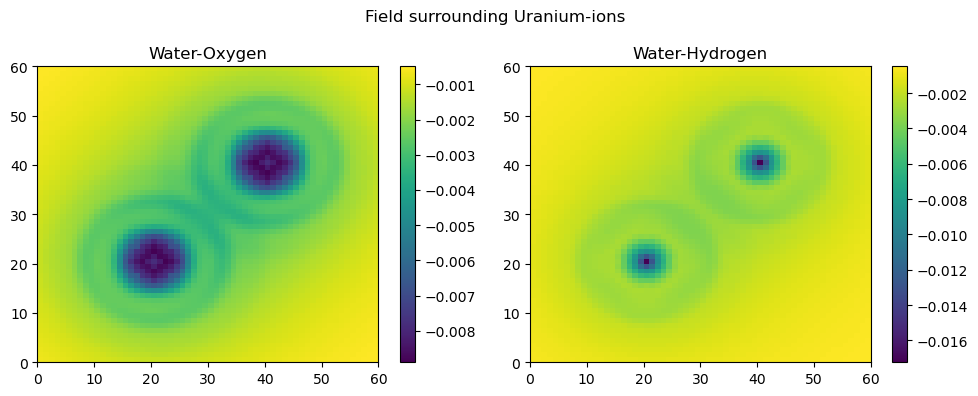

In [32]:
fig,axs = plt.subplots(1,2,figsize=(10,4))
for ind,ax in enumerate(axs.flatten()):
    p = ax.pcolormesh(dat[0][ind][30])
    fig.colorbar(p,ax=ax)
axs[1].set_title("Water-Hydrogen")
axs[0].set_title("Water-Oxygen")
fig.suptitle("Field surrounding Uranium-ions")
fig.tight_layout()